<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/dp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1- Introduction + Set-up


In [1]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [2]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [3]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 160MB/s]



In [4]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

# 2- EDA

In [5]:

# check the folder strucutre
import os

base_path = "chest_xray"

for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()} FOLDER:")
    for label in os.listdir(os.path.join(base_path, split)):
        count = len(os.listdir(os.path.join(base_path, split, label)))
        print(f"  {label}: {count} images")


TRAIN FOLDER:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

VAL FOLDER:
  NORMAL: 8 images
  PNEUMONIA: 8 images

TEST FOLDER:
  NORMAL: 234 images
  PNEUMONIA: 390 images


**Note**
Dataset is already imnalanced, we have to shuffle and balance it...

## 2-2 Show sample images

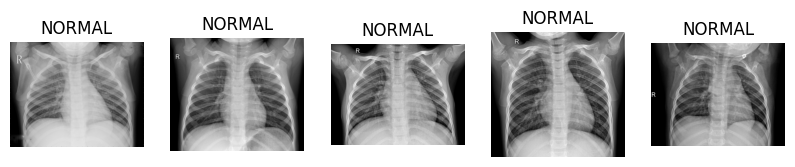

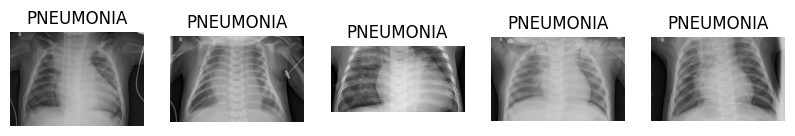

In [7]:
# show some sample images

import matplotlib.pyplot as plt
import cv2
import os

def show_samples(base_path, split, label):
    path = os.path.join(base_path, split, label)
    images = os.listdir(path)[:5]  # show 5 images

    plt.figure(figsize=(10, 3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')

    plt.show()

show_samples(base_path, 'train', 'NORMAL')
show_samples(base_path, 'train', 'PNEUMONIA')

**Note**  
Images are clear, mostly, and some of them do not have the same size

##  2-3 Check image sizes (CRUCIAL before model)

In [8]:
sizes = []

for label in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_path, 'train', label)

    for img_name in os.listdir(path)[:100]:  # sample 100
        img = cv2.imread(os.path.join(path, img_name))
        sizes.append(img.shape)

print(set(sizes))

{(1654, 1828, 3), (1141, 1430, 3), (656, 1088, 3), (664, 1016, 3), (1348, 1608, 3), (674, 1152, 3), (744, 1128, 3), (998, 1392, 3), (1271, 1554, 3), (576, 816, 3), (984, 1360, 3), (640, 944, 3), (1882, 2048, 3), (1330, 1712, 3), (1708, 1944, 3), (1072, 1554, 3), (529, 831, 3), (1000, 1320, 3), (544, 840, 3), (1806, 1911, 3), (1082, 1318, 3), (728, 1080, 3), (600, 992, 3), (1156, 1646, 3), (581, 1028, 3), (1248, 1724, 3), (1777, 2048, 3), (1558, 1816, 3), (1158, 1386, 3), (776, 1392, 3), (752, 1160, 3), (720, 1008, 3), (1071, 1454, 3), (1700, 2110, 3), (1410, 1820, 3), (1160, 1416, 3), (1383, 1566, 3), (1418, 1808, 3), (1306, 1596, 3), (1542, 1808, 3), (672, 904, 3), (1047, 1372, 3), (1044, 1467, 3), (832, 992, 3), (1163, 1468, 3), (528, 912, 3), (664, 968, 3), (792, 1256, 3), (1970, 2178, 3), (1357, 1886, 3), (680, 1128, 3), (1164, 1372, 3), (1815, 1857, 3), (824, 1176, 3), (1777, 1952, 3), (740, 1118, 3), (832, 1392, 3), (1314, 1546, 3), (1480, 1858, 3), (1182, 1426, 3), (728, 1208, 3

**Note** as we can clrearly see now, they absolutely DO NOT have a uniform size, so we have to consifer this

**Note** Skipping Pixel Distrubution due to not enough RAM

# 3- Pre Processing Section
Proper Split,
Preprocessing,
Normalization

## 3-1 Count original splits

In [9]:
# count original splits
import os
from collections import Counter

base_path = "chest_xray"

def count_split(split):
    counts = {}
    for label in os.listdir(os.path.join(base_path, split)):
        path = os.path.join(base_path, split, label)
        counts[label] = len(os.listdir(path))
    return counts

print("ORIGINAL TRAIN:", count_split("train"))
print("ORIGINAL VAL:", count_split("val"))
print("ORIGINAL TEST:", count_split("test"))

ORIGINAL TRAIN: {'NORMAL': 1341, 'PNEUMONIA': 3875}
ORIGINAL VAL: {'NORMAL': 8, 'PNEUMONIA': 8}
ORIGINAL TEST: {'NORMAL': 234, 'PNEUMONIA': 390}


Check new data (memory)

## 3-2 Prprocessing

In [10]:
#imports

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:

# ⚙️ PREPROCESSING PIPELINE


# Training generator (includes normalization + augmentation later if needed)
train_datagen = ImageDataGenerator(
    rescale=1./255   # 🔥 normalize pixels (0–255 → 0–1)
)

# Validation generator (ONLY normalization)
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [12]:
# 📊 LOAD DATA (WITH SPLIT BUILT-IN)

train_generator = train_datagen.flow_from_directory(
    "chest_xray/train",   # original train folder
    target_size=(64, 64),  # 🔥 resize all images
    batch_size=32,
    class_mode='binary',
    subset=None   # we will not use built-in split here
)

Found 5216 images belonging to 2 classes.


In [13]:
#
# 📊 TRAIN + VAL SPLIT INSIDE GENERATOR

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 🔥 80/20 split
)

train_generator = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='training'   # 🔥 training part
)

val_generator = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # 🔥 validation part
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


In [14]:
# NEW

# Now we do all of these new steps instead
# ADD THIS as a new cell right after ↑
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_array = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_array),
    y=train_labels_array
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)
print("Class mapping:", train_generator.class_indices)

Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


**Note** We want to resize to (64, 64) to make the images smaller

In [15]:
# ================================
# 🧪 TEST GENERATOR
# ================================

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "chest_xray/test",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # ❗ important for evaluation
)

Found 624 images belonging to 2 classes.


In [16]:
# Get a batch (images + labels)
images, labels = next(test_generator)

In [17]:
print(images.shape)

(32, 64, 64, 3)


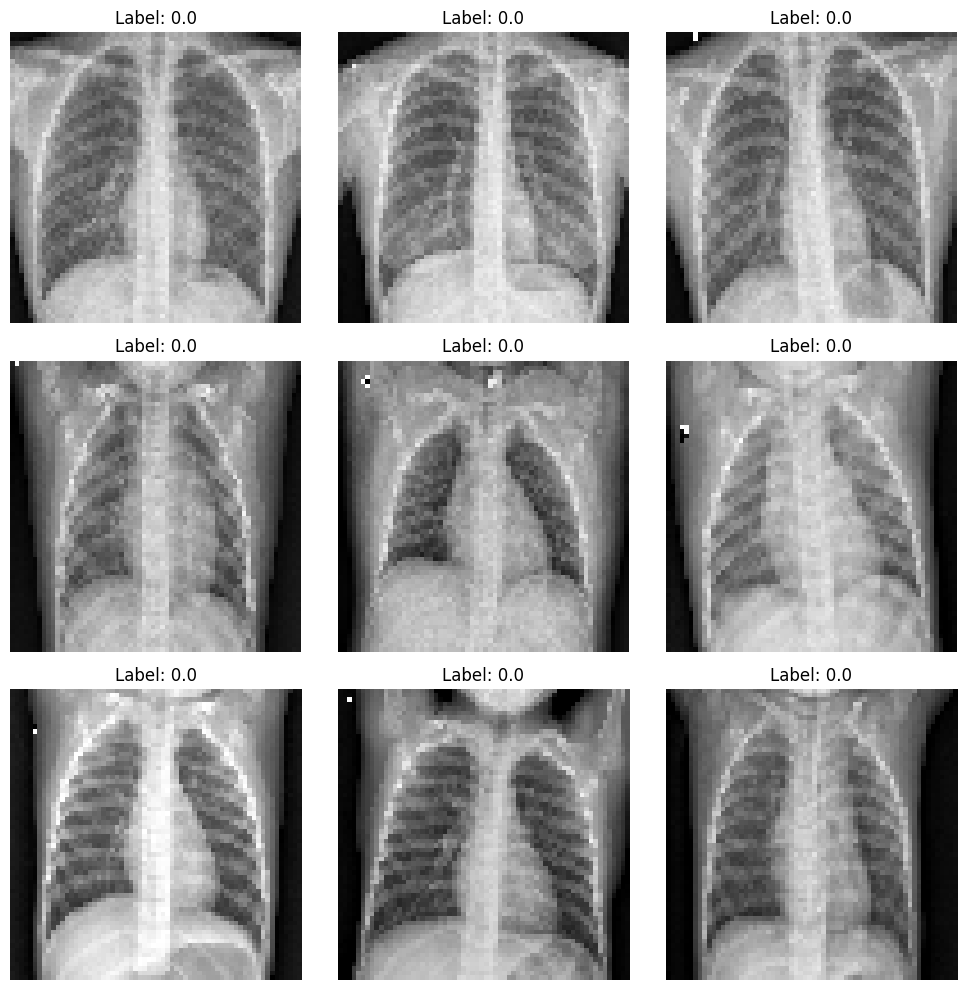

In [18]:
import matplotlib.pyplot as plt

# Get a batch
images, labels = next(test_generator)

# Show first 9 images
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 4- Fitting and Training

## 1- Baseline model (ANN)

In [ ]:
# using keras
import tensorflow as tf
from tensorflow import keras

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[64, 64, 3]),

    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dropout(0.2),    # randomly dropout 20%

    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.2),    # randomly dropout 20%

    keras.layers.Dense(1, activation="sigmoid") # best for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     3,686,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,716,901 (14.18 MB)

 Trainable params: 3,716,901 (14.18 MB)

 Non-trainable params: 0 (0.00 B)

**NOTES**
- lots of parameters, we expect overfitting of course.
- we might need to do dropping and l1/l2

In [ ]:
# let us try to train the model without any reglization, well excpet droput
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])


**NOTES**
- binary_crossentropy as the loss function, the name is self explanotary
- adam is really good for binary classification
- We might wanna adjust the learning rate


In [ ]:
# fitting the model
history = model.fit(train_generator, validation_data=val_generator, epochs=30, class_weight=class_weights_dict)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 447ms/step - accuracy: 0.7601 - loss: 0.6354 - val_accuracy: 0.8955 - val_loss: 0.2558
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 431ms/step - accuracy: 0.8807 - loss: 0.2863 - val_accuracy: 0.8466 - val_loss: 0.3352
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 440ms/step - accuracy: 0.9116 - loss: 0.2199 - val_accuracy: 0.9377 - val_loss: 0.1743
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 434ms/step - accuracy: 0.9065 - loss: 0.2409 - val_accuracy: 0.8706 - val_loss: 0.3064
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 61s 466ms/step - accuracy: 0.9152 - loss: 0.2149 - val_accuracy: 0.8974 - val_loss: 0.2638
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.9197 - loss: 0.1937 - val_accuracy: 0.9214 - val_loss: 0.1940
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 434ms/step - accuracy: 0.8907 - loss: 0.2400 - val_accuracy: 0.9406 - val_loss: 0.1684
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 444ms/step - accuracy: 0.8641 - loss: 0

**Note** clear overfitting, time for the graphs

### Overfitting Graphs

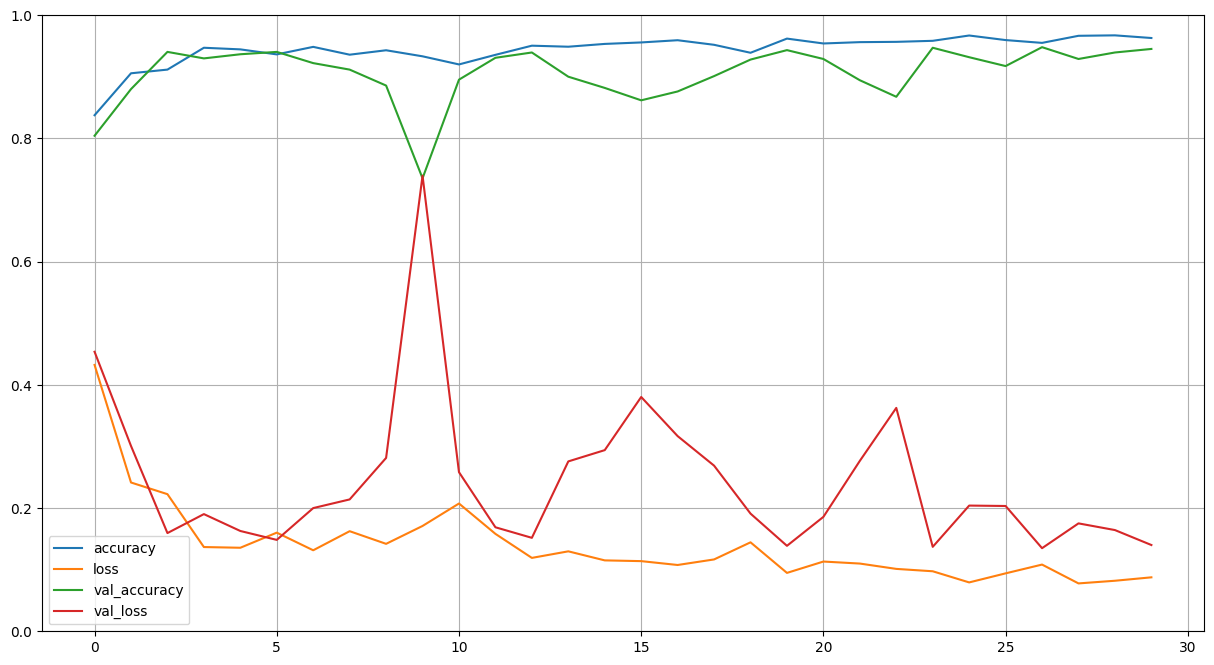

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

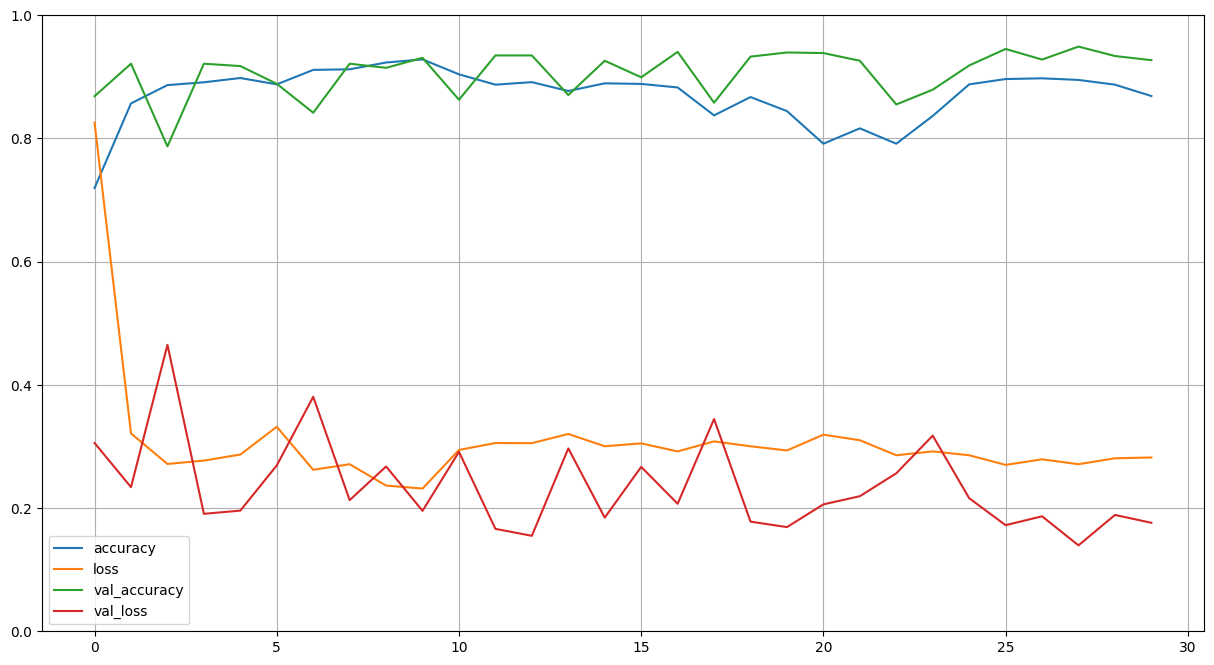

In [ ]:
# after dropout
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

**Note**
- Signs of underfitting this time around, let us bring the drop out rate down a notch

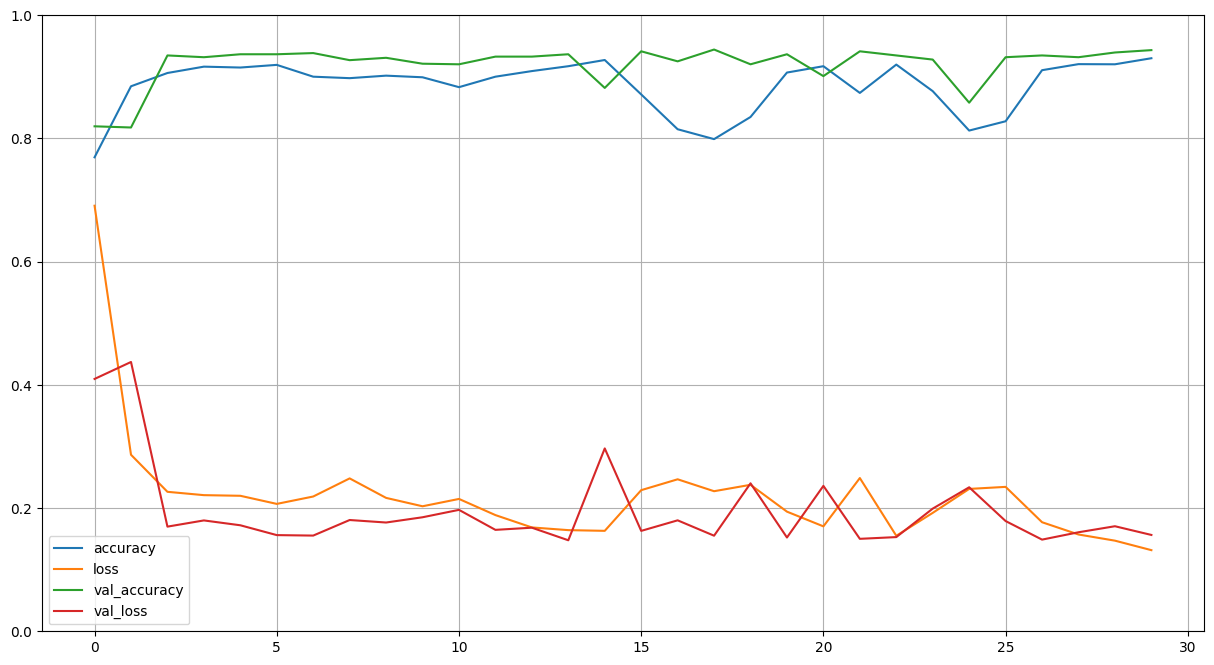

In [ ]:
# after 20% drop out (not underfitting really)
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

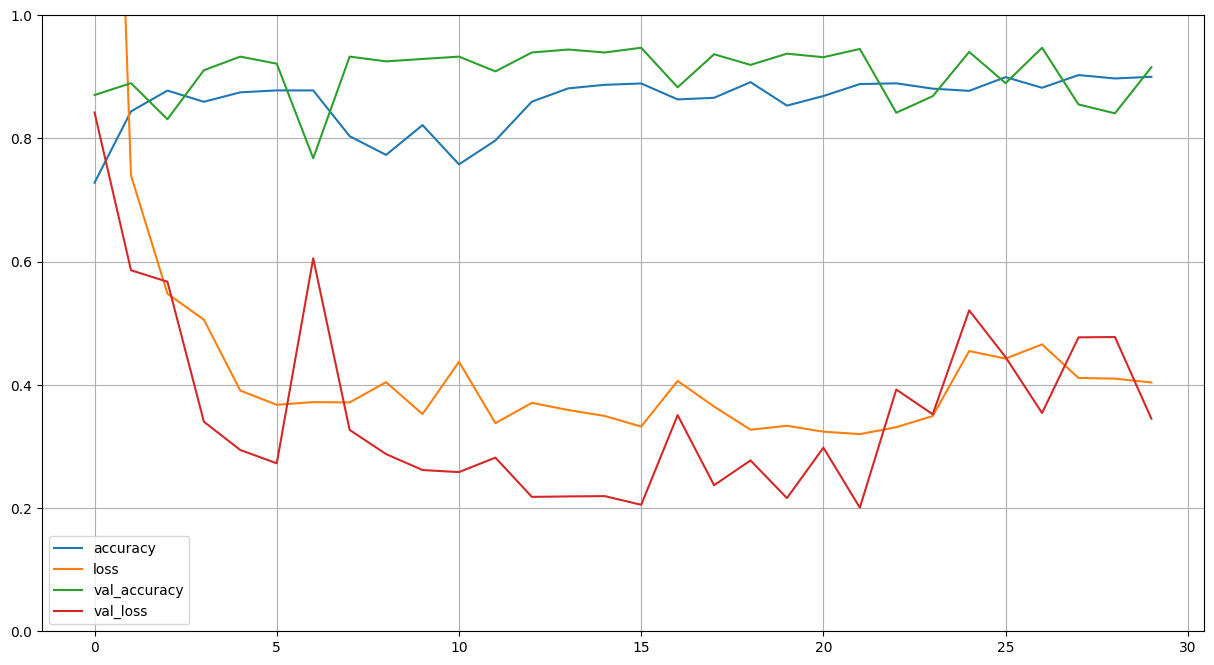

In [ ]:
# graph after l2 reg
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

**Notes**
to be fair, we did not choose the alpha value, but since our 20% frop out model was good enough, based on the graph, we should keep that

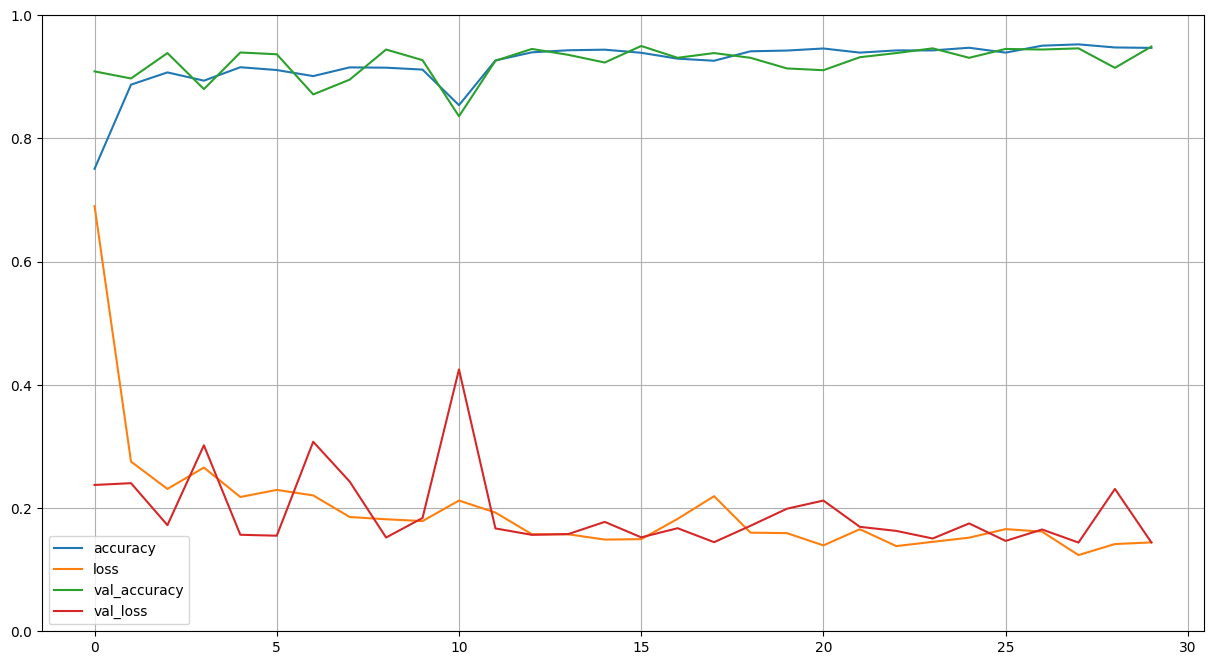

In [ ]:
# checking if the 20% dropout model is still solid
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step


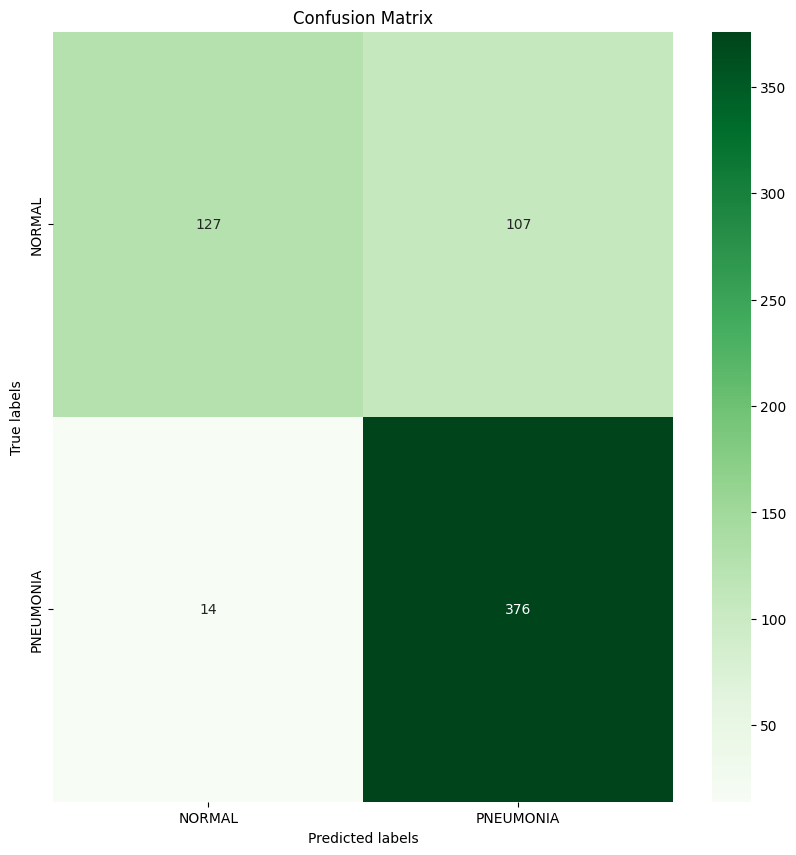

In [ ]:
# confusion matrix
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1 - get predictions from the model
predictions = model.predict(test_generator)

# 2 - convert probabilities to class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# 3 - get the true labels from the generator
true_classes = test_generator.classes

# 4 - class names in the right order
class_names = ['NORMAL', 'PNEUMONIA']  # 0=NORMAL, 1=PNEUMONIA

# 5 - compute the matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 6 - plot it
plt.figure(figsize=(6, 4))
fig = sb.heatmap(cm, annot=True, fmt='g', cmap='Greens')

fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
fig.xaxis.set_ticklabels(class_names)
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)

plt.show()

**NOTES**
In medics, We do not wanna to tell a sick person that he's fine

### Testing the model with external images

In [ ]:
from PIL import Image
import numpy as np

# load and preprocess your image to match our model's expected input
img = Image.open("n1.jpeg").convert("RGB")   # RGB not grayscale — our model expects 3 channels (64x64x3)
img = img.resize((64, 64))                     # resize to 64x64 — must match target_size in your generators
img_array = np.array(img) / 255.0             # normalize to [0, 1] — same as rescale=1./255 in the generator

# predict
prediction = model.predict(img_array.reshape(1, 64, 64, 3))  # shape: (1, 64, 64, 3) — the 1 is the batch dimension
probability = prediction[0][0]                                 # single value between 0 and 1

# interpret result
if probability > 0.5:
    print(f"Predicted: PNEUMONIA ({probability:.2%} confidence)")
else:
    print(f"Predicted: NORMAL ({1 - probability:.2%} confidence)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: NORMAL (99.97% confidence)


### Model Evaluation.

In [ ]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.90      0.54      0.68       234
   PNEUMONIA       0.78      0.96      0.86       390

    accuracy                           0.81       624
   macro avg       0.84      0.75      0.77       624
weighted avg       0.82      0.81      0.79       624



### Saving the ANN Model


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save('/content/drive/MyDrive/pneum-project/ann_v1.h5')

In [ ]:

# make sure the folder exists
import os

os.makedirs('/content/drive/MyDrive/pneum-project', exist_ok=True)

In [ ]:

# verify it was saved correctly
!ls /content/drive/MyDrive/pneum-project

ann_v1.h5


## 2- Intermmediate Model (CNN)




In [19]:
# using keras
import tensorflow as tf
from tensorflow import keras

In [20]:
inter_model2 = keras.models.Sequential([
    # new part: Features Extraction
    keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(64,64,3)), # numer of filters, size of filter window, activation function and input shape
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    # now we are in the fully connected layer
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu', kernel_regularizer='l2'),
    keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
inter_model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

**Notes**
We can clearly see we have way less parameters

**Note**
Batch Normalization does effect the learning rate?

In [22]:
# compiling the model
inter_model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',  # default is 0.001
    metrics=['accuracy']
)

In [23]:
# the 2nd old l2 model
inter_history2 = inter_model2.fit(train_generator, validation_data=val_generator, epochs=30, class_weight=class_weights_dict )


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 397ms/step - accuracy: 0.8529 - loss: 0.6211 - val_accuracy: 0.9501 - val_loss: 0.2744
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 381ms/step - accuracy: 0.9298 - loss: 0.2654 - val_accuracy: 0.9530 - val_loss: 0.2006
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 384ms/step - accuracy: 0.9470 - loss: 0.2030 - val_accuracy: 0.9569 - val_loss: 0.2087
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 383ms/step - accuracy: 0.9451 - loss: 0.2087 - val_accuracy: 0.8936 - val_loss: 0.3501
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 366ms/step - accuracy: 0.9504 - loss: 0.1914 - val_accuracy: 0.9118 - val_loss: 0.2846
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 382ms/step - accuracy: 0.9566 - loss: 0.1723 - val_accuracy: 0.9252 - val_loss: 0.2607
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 51s 392ms/step - accuracy: 0.9566 - loss: 0.1661 - val_accuracy: 0.9482 - val_loss: 0.1854
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 51s 391ms/step - accuracy: 0.9499 - loss: 0

**Note**
This graph is about the l2 and drop out functions

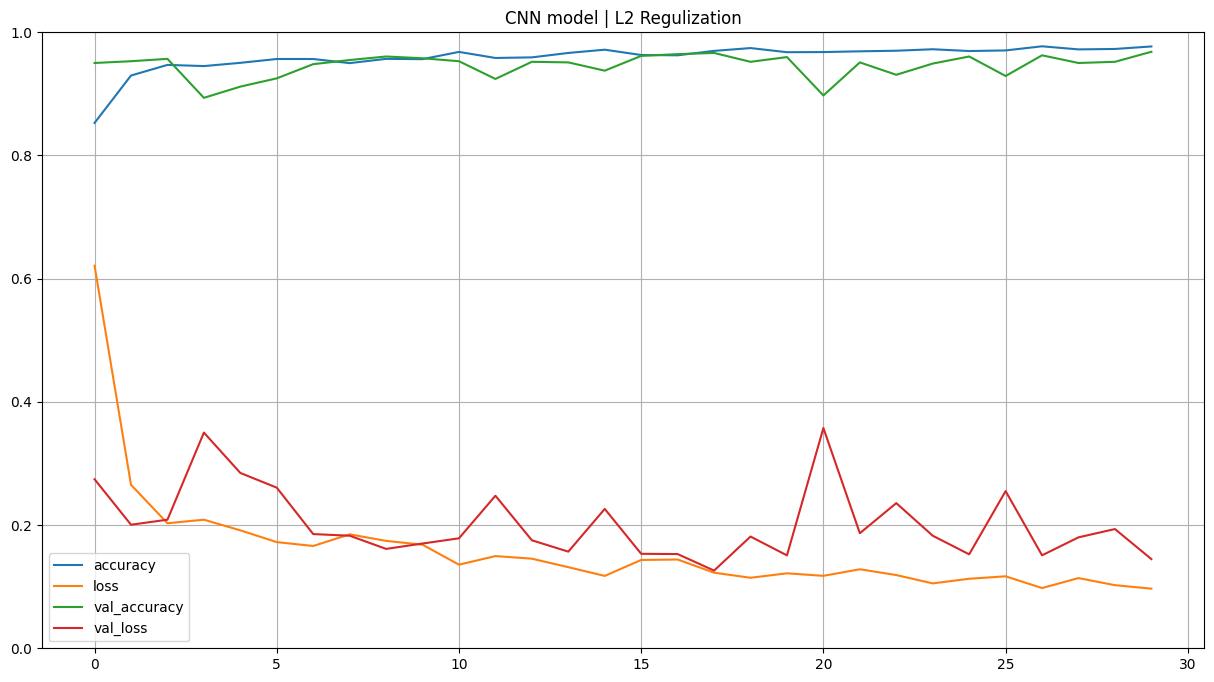

In [24]:
# let us check the graph l2
import pandas as pd
pd.DataFrame(inter_history2.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.title('CNN model | L2 Regulization')
plt.show()

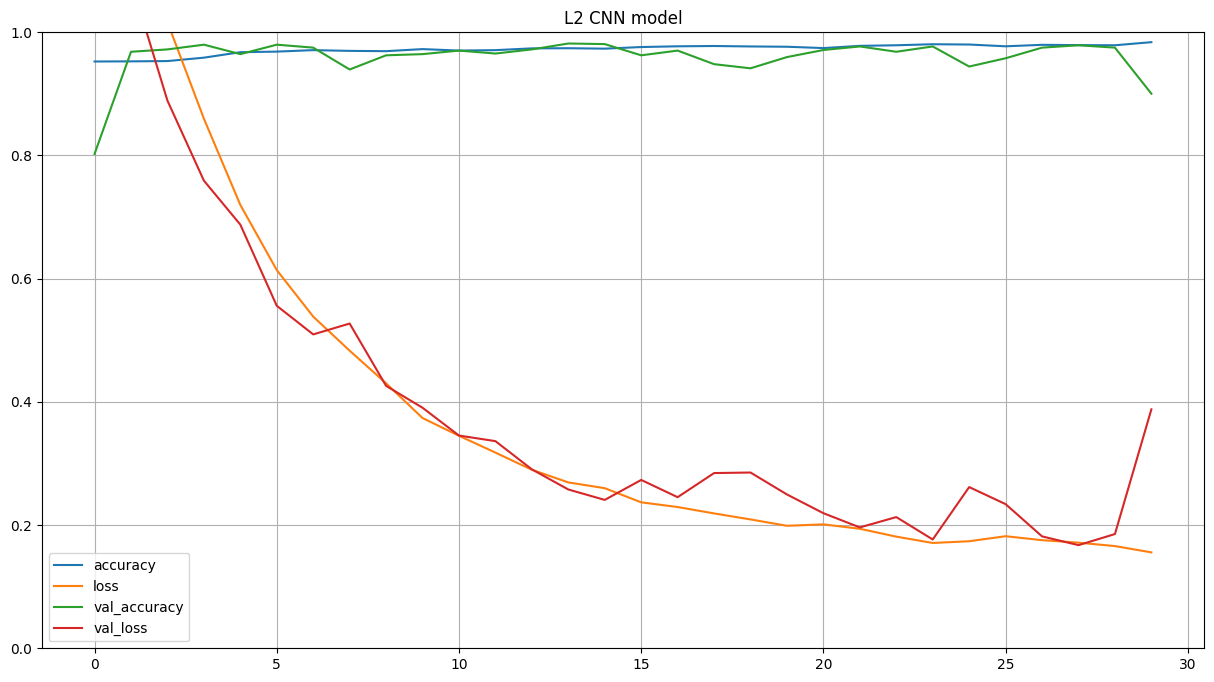

In [ ]:
# this is the graph for batch normalization model, batch + drop out + l2 with dropping the learning rate
# l2 inter_model
# WRONG ONE
import pandas as pd
pd.DataFrame(inter_history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.title('L2 CNN model')
plt.show()

**Notes**
- overfitting is solved, kinda we might keep this model
- try BN next

### Confusion Matrices (We have to do it for each model)

**Note**
The matrix is terrible let us check why

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step


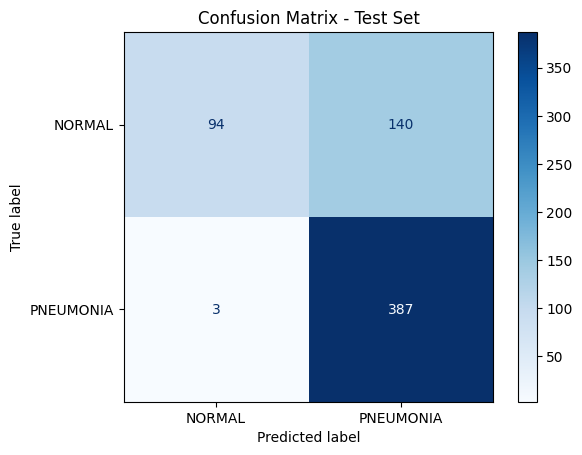

True NORMAL correctly predicted:     94
NORMAL wrongly predicted as PNEUMONIA: 140
PNEUMONIA wrongly predicted as NORMAL: 3
True PNEUMONIA correctly predicted:  387


In [26]:
# using the correct values
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Use test_generator, not val_generator
test_generator.reset()
y_pred = inter_model2.predict(test_generator)
y_pred_classes = (y_pred > 0.3).astype(int)  # 0.3 threshold — catches more PNEUMONIA
y_true = test_generator.classes

# Plot
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NORMAL', 'PNEUMONIA'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

# Print the numbers clearly too
print(f"True NORMAL correctly predicted:     {cm[0][0]}")
print(f"NORMAL wrongly predicted as PNEUMONIA: {cm[0][1]}")
print(f"PNEUMONIA wrongly predicted as NORMAL: {cm[1][0]}")
print(f"True PNEUMONIA correctly predicted:  {cm[1][1]}")

### Saving the CNN model

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
inter_model2.save('/content/drive/MyDrive/pneum-project/cnn_v2.h5')

In [30]:
# make sure the folder exists
import os

os.makedirs('/content/drive/MyDrive/pneum-project', exist_ok=True)

In [31]:
# verify it was saved correctly
!ls /content/drive/MyDrive/pneum-project

ann_v1.h5  cnn_v1.h5  cnn_v2.h5
